In [ ]:
import json
import pandas as pd

from tier2_concept_neighbours import OUTPUT_PATH as INPUT_PATH

with open(INPUT_PATH, "r") as f:
    data = json.load(f)

rows = []

for concept, payload in data["concepts"].items():
    for inst in payload["instances"]:
        for neigh in inst["neighbours"]:
            rows.append({
                "concept": concept,
                "source_token": inst["token"],
                "source_doc": inst["doc_id"],
                "neighbour_token": neigh["token"],
                 "similarity": neigh["similarity"],
            })

df = pd.DataFrame(rows)
df.head()


dict_keys(['k', 'concepts'])


,concept,source_token,source_doc,neighbour_token,similarity
0,PREROGATIVE,prerogatiue,A22453,prerogatiue,1.000000
1,PREROGATIVE,prerogatiue,A22453,prerogatiue,0.927922
2,PREROGATIVE,prerogatiue,A22453,statutes,0.925242
3,PREROGATIVE,prerogatiue,A22453,prerogatiue,0.921579
4,PREROGATIVE,prerogatiue,A22453,realme,0.919628


In [7]:
(
    df.groupby(["concept", "neighbour_token"])
      .size()
      .sort_values(ascending=False)
      .head(30)
)

concept     neighbour_token
DIVINE      god                117407
            lord                68743
PARLIAMENT  parliament          52294
MAN         man                 49901
KING        king                49719
PEOPLE      people              42211
CHURCH      church              32205
HOUSE       house               26500
LAW         law                 25275
TEMPORAL    state               16950
RELIGION    religion            15795
KING        kings               15203
TEMPORAL    government          14264
            kingdom             13995
DIVINE      holy                13971
TEMPORAL    authority           12813
PEOPLE      subjects            12705
RELIGION    faith               12077
DIVINE      heaven              11430
            grace               11325
LIBERTY     liberty              8360
LAW         laws                 7912
            lawes                7818
CHURCH      churches             6794
RELIGION    doctrine             6777
LIBERTY     liberties 

In [10]:
def field(concept, n=50):
    sub = df[df["concept"] == concept]

    return (
        sub.groupby("neighbour_token")
           .size()
           .sort_values(ascending=False)
           .head(n)
    )

# field("LAW")
field("LIBERTY")

neighbour_token
liberty          8360
liberties        6249
libertie          748
freedome           32
authoritie         30
power              21
authority          13
safetie            13
freedomes          13
freedom            11
autoritie          10
priviledges        10
securitie          10
limits              9
rights              9
priviledge          9
lawes               8
parishes            8
ordinances          8
mercy               7
prison              7
alhallowes          7
bodie               7
charitie            6
gates               6
mercie              6
boldnesse           6
uery                6
free                6
strength            6
bishopsgate         6
dutie               5
minories            5
pauls               5
aldersgate          5
goods               5
duty                4
honour              4
opportunitie        4
billingsgate        4
kingdomes           4
gift                4
prisoner            4
benefit             4
sauiours        

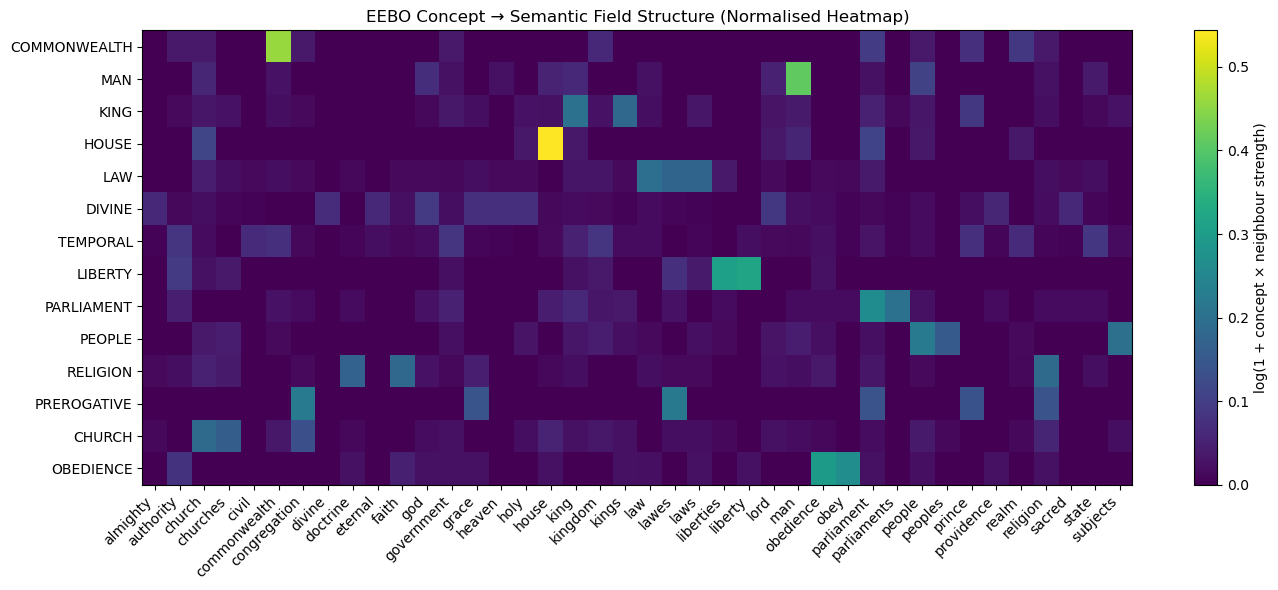

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Aggregate concept–neighbour relations
agg = (
    df.groupby(["concept", "neighbour_token"])
      .agg(
          count=("similarity", "size"),
          mean_sim=("similarity", "mean")
      )
      .reset_index()
)


# 2. Strength metric (frequency × similarity)
agg["strength"] = agg["count"] * agg["mean_sim"]


# 3. Select most globally informative neighbours
TOP_N = 40

top_neighbours = (
    agg.groupby("neighbour_token")["strength"]
       .sum()
       .sort_values(ascending=False)
       .head(TOP_N)
       .index
)

filtered = agg[agg["neighbour_token"].isin(top_neighbours)]


# 4. Pivot to concept × neighbour matrix
matrix = (
    filtered.pivot(
        index="concept",
        columns="neighbour_token",
        values="strength"
    )
    .fillna(0)
)


# 5. log scaling (recommended for EEBO skew)
matrix = np.log1p(matrix)

# 5b. Row-normalisation (concept-wise semantic composition)
# This removes frequency dominance and makes each row comparable
matrix = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)

# 6. Sort concepts by overall semantic activity
matrix = matrix.loc[
    matrix.sum(axis=1)
           .sort_values(ascending=False)
           .index
]


# 7. Plot heatmap
plt.figure(figsize=(14, 6))
plt.imshow(matrix.values, aspect="auto")

plt.yticks(
    range(len(matrix.index)),
    matrix.index
)

plt.xticks(
    range(len(matrix.columns)),
    matrix.columns,
    rotation=45,
    ha="right"
)

plt.colorbar(label="log(1 + concept × neighbour strength)")

plt.title("EEBO Concept → Semantic Field Structure (Normalised Heatmap)")

plt.tight_layout()
plt.show()